Draw + FFT time: 23.5488 seconds
Conv time: 28.1799 seconds
GalSim draw time: 0.0160 seconds
Mode: with pixel
PSF method: real-space FFT
Supersample: 256
GalSim flux: 0.99896991
FFT flux:    0.99897554
Max abs residual: 3.134e-06
Max abs residual as % of max flux: 0.008%


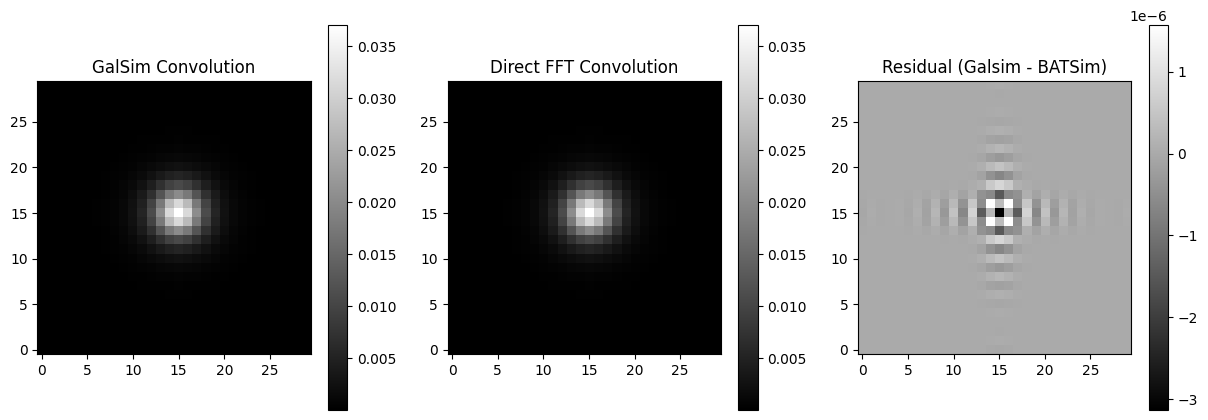

In [1]:
import galsim
import numpy as np
from time import time
import matplotlib.pyplot as plt

use_pixel = True   # Whether to include the pixel response
kpsf = False       # Whether to draw the PSF directly in k-space
supersample = 256    # Super-sample grid size for direct FFT approach
pad = 16           # Extra padding around image to ignore distant flux from FFTs
scale = 0.2        # Pixel scale of the output image

# Construct psf and galaxy profiles
psf = galsim.Moffat(beta=3.5, fwhm=0.7)
gal = galsim.Sersic(n=2, half_light_radius=0.2, flux=1).shear(g1=0.02)
objs = [gal, psf]
conv_gal = galsim.Convolve(objs)

# Determine image size
# Use the convolved profile's own good image size rather than the pre-convolution galaxy size.
size = conv_gal.getGoodImageSize(scale)
fft_size = size + 2*pad
fine_scale = scale / supersample
fine_fft_size = fft_size * supersample
dk = 2 * np.pi / (fine_fft_size * fine_scale)

start = time()
# Draw the galaxy without pixel convolution.
gal_im = gal.drawImage(nx=fine_fft_size, ny=fine_fft_size, scale=fine_scale,
                       method="no_pixel", use_true_center=False).array
gal_fft = galsim.fft.fft2(gal_im, shift_in=True, shift_out=True)

# Draw the PSF either directly in k-space or in real space and then fft.
if kpsf:
    psf_fft = psf.drawKImage(nx=fine_fft_size, ny=fine_fft_size, scale=dk).array
else:
    psf_im = psf.drawImage(nx=fine_fft_size, ny=fine_fft_size, scale=fine_scale,
                           method="no_pixel", use_true_center=False).array
    psf_fft = galsim.fft.fft2(psf_im, shift_in=True, shift_out=True)

# Draw the pixel if requested.
if use_pixel:
    # Draw the pixel directly in Fourier space, rather than use fft2.
    # The direct fft doesn't work especially well with only a single non-zero pixel.
    # (Nor even when supersampling to sxs pixels.)
    pix_fft = galsim.Pixel(scale).drawKImage(nx=fine_fft_size, ny=fine_fft_size, scale=dk).array
end = time()
print(f"Draw + FFT time: {end - start:.4f} seconds")

start = time()
# Convolve and IFFT
bat_conv_fft = gal_fft * psf_fft
if use_pixel:
    bat_conv_fft *= pix_fft
bat_conv_im = galsim.fft.ifft2(bat_conv_fft, shift_in=True, shift_out=True).real

# Recover the coarse-grid image by taking the matching fine-grid sample phase and multiplying by
# the area ratio.
if supersample > 1:
    bat_conv_im = (supersample**2) * bat_conv_im[::supersample, ::supersample]
end = time()
print(f"Conv time: {end - start:.4f} seconds")

start = time()
# Draw a padded GalSim image too
draw_method = "auto" if use_pixel else "no_pixel"
gal_conv_im = conv_gal.drawImage(
    nx=fft_size, ny=fft_size, scale=scale, method=draw_method, use_true_center=False
).array
end = time()
print(f"GalSim draw time: {end - start:.4f} seconds")

# Crop both images to the same central region before computing the residual.
gal_conv_im = gal_conv_im[pad:pad+size, pad:pad+size]
bat_conv_im = bat_conv_im[pad:pad+size, pad:pad+size]
residual = gal_conv_im - bat_conv_im
print(f"Mode: {'with pixel' if use_pixel else 'no pixel'}")
print(f"PSF method: {'k-space' if kpsf else 'real-space FFT'}")
print(f"Supersample: {supersample}")
print(f"GalSim flux: {gal_conv_im.sum():.8f}")
print(f"FFT flux:    {bat_conv_im.sum():.8f}")
print(f"Max abs residual: {abs(residual).max():.3e}")

perc_residual = 100 * abs(residual).max() / gal_conv_im.max()
print(f"Max abs residual as % of max flux: {perc_residual:.3f}%")

# Plot
plt.subplots(1, 3, figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(gal_conv_im, origin='lower', cmap='gray')
plt.colorbar()
plt.title("GalSim Convolution")
plt.subplot(1, 3, 2)
plt.imshow(bat_conv_im, origin='lower', cmap='gray')
plt.colorbar()
plt.title("Direct FFT Convolution")
plt.subplot(1, 3, 3)
plt.imshow(residual, origin='lower', cmap='gray')
plt.colorbar()
plt.title("Residual (Galsim - BATSim)")
plt.savefig('charlie.png')

In [2]:
# Measure shear using adaptive moments on both images
psf_final_im = psf.drawImage(
    nx=fft_size, ny=fft_size, scale=scale, method=draw_method, use_true_center=False
).array
psf_final_im = psf_final_im[pad:pad+size, pad:pad+size]

# create galsim images from all arrays
psf_final_im = galsim.Image(psf_final_im, scale=scale)
bat_conv_im = galsim.Image(bat_conv_im, scale=scale)
gal_conv_im = galsim.Image(gal_conv_im, scale=scale)

manual_result = galsim.hsm.EstimateShear(bat_conv_im, psf_final_im)
print(manual_result.observed_shape)

galsim_result = galsim.hsm.EstimateShear(gal_conv_im, psf_final_im)
print(galsim_result.observed_shape)

manual_g1 = manual_result.observed_shape.g1
galsim_g1 = galsim_result.observed_shape.g1

perc_diff_g1 = 100 * abs(manual_g1 - galsim_g1) / abs(galsim_g1)
print(f"Percentage difference in g1: {perc_diff_g1:.2f}%")

galsim.Shear(g1=0.004824522485723136,g2=-4.795381291994292e-14)
galsim.Shear(g1=0.004824534593762056,g2=-4.8053450036177683e-14)
Percentage difference in g1: 0.00%


galsim.Shear(g1=0.02698008192948362,g2=-4.3253633125057155e-12)


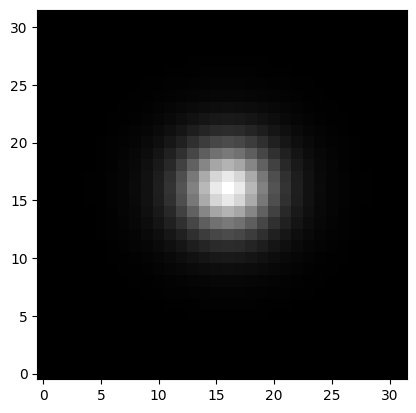

In [3]:
galaxy = galsim.Sersic(n=1, half_light_radius=0.5, flux=1).shear(g1=0.05)
psf = galsim.Moffat(beta=3.5, fwhm=0.7)
final = galsim.Convolve(galaxy, psf)
final_image = final.drawImage(scale=0.2, use_true_center=False)
final_epsf_image = psf.drawImage(scale=0.2, use_true_center=False)
result = galsim.hsm.EstimateShear(final_image, final_epsf_image)

print(result.observed_shape)

plt.imshow(final_image.array, origin='lower', cmap='gray')